In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Initialises the random number generator using the newer, more robust 'default_rng' method

rng = np.random.default_rng(0) 

In [2]:
time = np.arange('2020-01', '2020-07', dtype='datetime64[M]') # Sets range between Jan and July in 2020
y = np.linspace(70.0, 68.0, 40) # latitude, north to south (40 y-increments)
x = np.linspace(120.0, 124.0, 50) # longitude (50 x-increments)

# A smooth field plus a warming trend plus noise

# base - A set of cosine values (same size as y (40)) are created, is shaped into a vertical (y) column vector, 
# then multiplied by a horizontal (x) column vector (same size as x (50)) made up of 1s.

# This is broadcasting - Stretches the column and row vectors into a 40 x 50 (y,x) array with cos values
# repeating along the rows (due to the stretching/duplicating and multiplying by 1 i.e. no cos value change).

base = np.cos(np.linspace(0, 3, y.size))[:, None] * np.ones(x.size)[None, :]

# trend - A range of integers from 0 to the size of the time array (7) is created, this is mapped 
# onto the 'z' dimension of a 3D array (with no columns or rows). Multiplies all of these values by 0.3.

# This simulates the temperature increasing by 0.3 degrees each month (starting with 0.3), 
# as the z axis will contain values of temperature for the range of months specified.

trend = np.arange(time.size)[:, None, None] * 0.3

# This produces the synthetic 3D array we will be working with. First by converting the base 2D array into a 3D array (a single slice) and multiplying all values by 5.
# These arrays are then broadcasted i.e. the base (yx) array is duplicated across the z-axis, while the trend (z) array is duplicated across the x-y plane, then added. 
# This creates an array where the largest values are at the top (cos(0)) and these decrease as a cos function, with each of these values increasing by 0.3
# for each time increment/z-index (each month). 
# Random numbers are then selected from a normal distribution using the random number generator defined earlier. The numbers will have a mean of 0, a s.d. of 0.4, and the 
# same shape as our dataset. 

# We now have a set of synthetic temperatures that display a warming trend with some noise.

temp_data = base[None] * 5 + trend + rng.normal(0, 0.4, (time.size, y.size, x.size))


# We now create a DataArray from the data. 
# We pass the temperature data and specify the dimensions (axes) i.e. the independent variables (time, y , x).
# We also specify the coordinates (values) for each of these dimensions (axes) (the actual time, y and x values). 
# Finally, we give the DataArray a name (lst) and add some attributes (units and long_name).

da = xr.DataArray(
temp_data,
dims=('time', 'y', 'x'),
coords={'time': time, 'y': y, 'x': x},
name='lst',
attrs={'units': 'degC', 'long_name': 'land surface temperature'},
)

da

<xarray.DataArray 'lst' (time: 6, y: 40, x: 50)> Size: 96kB
array([[[ 5.05029209,  4.94715805,  5.25616906, ...,  5.78410333,
          5.72065395,  5.52604151],
        [ 5.12816656,  4.50188694,  4.98343274, ...,  4.75100286,
          4.44872651,  4.42460631],
        [ 5.14201816,  5.33683023,  4.87522718, ...,  4.89737913,
          4.61945228,  5.37301038],
        ...,
        [-4.57860931, -4.72073469, -4.67102049, ..., -4.78853525,
         -4.23179656, -4.39830501],
        [-4.88036074, -4.94738892, -5.00781559, ..., -5.40367598,
         -5.75017847, -5.19158242],
        [-4.61223911, -4.54912639, -4.6340379 , ..., -5.75748713,
         -5.31373351, -4.80227075]],

       [[ 5.46770193,  5.09910218,  4.95692002, ...,  5.42307001,
          5.62064022,  5.3500086 ],
        [ 5.41269126,  5.8164882 ,  4.92440567, ...,  5.06431991,
          4.6213078 ,  4.83560746],
        [ 5.6564335 ,  5.11242398,  4.64843098, ...,  4.85013744,
          5.05576372,  4.98559284],
...
        [-3.87513738, -3.39393541, -3.75561678, ..., -4.40770149,
         -3.74830644, -3.13902868],
        [-3.58646233, -3.43837226, -4.02877415, ..., -3.68973622,
         -4.31784813, -3.49671989],
        [-3.58997693, -3.4589942 , -4.42368367, ..., -3.91650912,
         -4.25648269, -3.33747024]],

       [[ 6.69576305,  5.96538144,  6.05446765, ...,  5.66098726,
          7.0377784 ,  6.51152626],
        [ 6.32365922,  6.91697211,  6.25123584, ...,  6.23655826,
          6.78348989,  6.74306683],
        [ 6.20670569,  6.3064159 ,  6.79194742, ...,  6.25068153,
          6.19131267,  6.68259669],
        ...,
        [-2.46183468, -3.2227078 , -2.87218791, ..., -3.60911083,
         -4.42653677, -3.41509719],
        [-3.43305206, -3.09623334, -3.34256993, ..., -3.01228987,
         -3.06097787, -3.07299215],
        [-3.56782489, -4.15188174, -3.14622198, ..., -3.33326339,
         -2.79039778, -3.28744317]]], shape=(6, 40, 50))
Coordinates:
  * time     (time) datetime64[s] 48B 2020-01-01 2020-02-01 ... 2020-06-01
  * y        (y) float64 320B 70.0 69.95 69.9 69.85 ... 68.15 68.1 68.05 68.0
  * x        (x) float64 400B 120.0 120.1 120.2 120.2 ... 123.8 123.9 124.0
Attributes:
    units:      degC
    long_name:  land surface temperature

In [ ]:
# Mean over time -> creates a 2D (y, x) map of mean temperature across the 6 months for each location (y,x)

#mean_map = da.mean('time')

# Groups the time dimension of the data array into quarterly buckets (QS - Quarter Start) and as this array contains
# 6 months of data, it splits it into 2 seasons (Winter and Spring)

mean_map = da.resample(time='QS').mean()     

# Creates a 1D time series of the temp at the point closes to 69N, 122E

point = da.sel(y=69.0, x=122.0, method='nearest')


# Produces a time series of the mean temp across the whole region

series = da.mean(('y', 'x'))

series

#two_season_series = da.resample(time='QS').mean(('y', 'x')), #doesn't change the shape, should produce two points, not 6


# Prints the shape (size) of the Time mean, time series, and Spatial mean (average time series)

print(mean_map.shape, point.shape, series.shape)

(2, 40, 50) (6,) (6,)


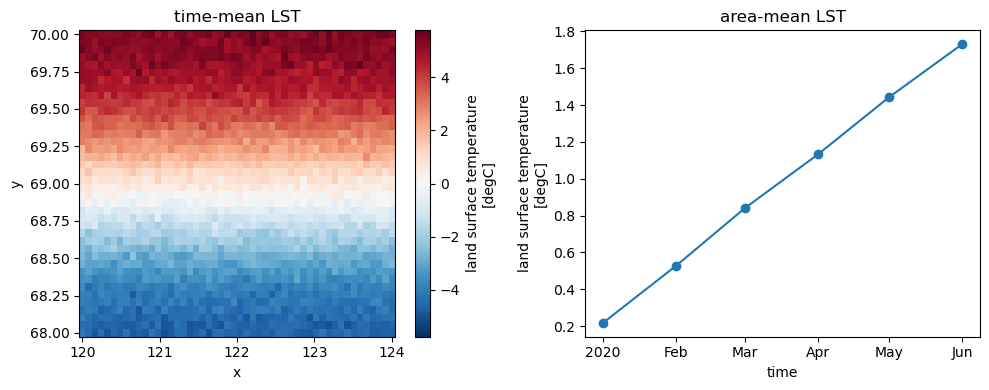

In [5]:
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 4))       # Sets up two subplots (a and b) in a 1 x 2 figure of a set size
mean_map[0].plot(ax=a)                                     # Assigns the mean over time plot for winter to subplot a
series.plot(ax=b, marker='o')                              # Assigns the mean over area plot to subplot b 
a.set_title('time-mean LST'); b.set_title('area-mean LST') # Sets the title for both subplots
plt.tight_layout()                                         # Auto-fits subplots into figure area

# plt.subplot returns two objects, a figure and the axes. You can use fig to apply attributes to the whole plot or
# to save the entire image. (a,b) unpacks the axes array so that a is the right plot, b is the left plot.

# xarray passes the dimensions of the array to matplotlib which (usually, unless there are some indexing issues) plots
# a heatmap for a 2D array and a line graph for a 1D array (it does this as xarray wraps matplotlib)

Text(0.5, 1.0, 'Mean LST on a polar projection')

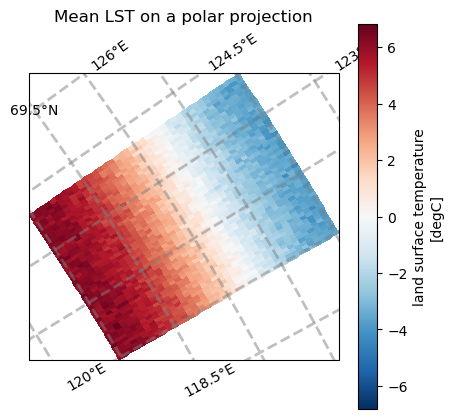

In [8]:
# Example: plot on a North Polar Stereographic projection.

# Sets up a figure of size 5 x 5 inches
# Sets the projection for the axes to NorthPolarStereo
# The PlateCarree transform maps the data to lat, lon (as the data is defined in degrees)

fig = plt.figure(figsize=(5, 5))                   
ax = plt.axes(projection=ccrs.NorthPolarStereo())  
mean_map[1].plot(ax=ax, transform=ccrs.PlateCarree()) 
ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
ax.coastlines()                                    
ax.set_title('Mean LST on a polar projection')     

In [21]:
# Converts a data array as data set, then writes the data set to netCDF4 file (standard format for EO data)

#da.to_dataset().to_netcdf('example_lst.nc')
reloaded = xr.open_dataset('/data/dte/crtg2/Training/Outputs/example_lst.nc')
reloaded

<xarray.Dataset> Size: 97kB
Dimensions:  (time: 6, y: 40, x: 50)
Coordinates:
  * time     (time) datetime64[ns] 48B 2020-01-01 2020-02-01 ... 2020-06-01
  * y        (y) float64 320B 70.0 69.95 69.9 69.85 ... 68.15 68.1 68.05 68.0
  * x        (x) float64 400B 120.0 120.1 120.2 120.2 ... 123.8 123.9 124.0
Data variables:
    lst      (time, y, x) float64 96kB ...